In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


In [2]:
## Download Data From here https://www.kaggle.com/competitions/pubg-finish-placement-prediction
df = pd.read_csv('train_V2.csv')

In [3]:
df.info() ## Check the memory consume by dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4446966 entries, 0 to 4446965
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Id               object 
 1   groupId          object 
 2   matchId          object 
 3   assists          int64  
 4   boosts           int64  
 5   damageDealt      float64
 6   DBNOs            int64  
 7   headshotKills    int64  
 8   heals            int64  
 9   killPlace        int64  
 10  killPoints       int64  
 11  kills            int64  
 12  killStreaks      int64  
 13  longestKill      float64
 14  matchDuration    int64  
 15  matchType        object 
 16  maxPlace         int64  
 17  numGroups        int64  
 18  rankPoints       int64  
 19  revives          int64  
 20  rideDistance     float64
 21  roadKills        int64  
 22  swimDistance     float64
 23  teamKills        int64  
 24  vehicleDestroys  int64  
 25  walkDistance     float64
 26  weaponsAcquired  int64  
 27  winPoints   

In [4]:
## Convert the columns with dtypes int64 to int32 and check the memory size
df = df.astype({col: 'int32' for col in df.select_dtypes('int64').columns})

In [5]:
## Check the memory consume  after converting int64 to int32 dataframe
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4446966 entries, 0 to 4446965
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Id               object 
 1   groupId          object 
 2   matchId          object 
 3   assists          int32  
 4   boosts           int32  
 5   damageDealt      float64
 6   DBNOs            int32  
 7   headshotKills    int32  
 8   heals            int32  
 9   killPlace        int32  
 10  killPoints       int32  
 11  kills            int32  
 12  killStreaks      int32  
 13  longestKill      float64
 14  matchDuration    int32  
 15  matchType        object 
 16  maxPlace         int32  
 17  numGroups        int32  
 18  rankPoints       int32  
 19  revives          int32  
 20  rideDistance     float64
 21  roadKills        int32  
 22  swimDistance     float64
 23  teamKills        int32  
 24  vehicleDestroys  int32  
 25  walkDistance     float64
 26  weaponsAcquired  int32  
 27  winPoints   

In [6]:
## Convert the columns with dtypes float64 to float32 and check the memory size
df = df.astype({col: 'float32' for col in df.select_dtypes('float64').columns})

In [7]:
## Check the memory consume  after converting float64 to float32 dataframe
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4446966 entries, 0 to 4446965
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Id               object 
 1   groupId          object 
 2   matchId          object 
 3   assists          int32  
 4   boosts           int32  
 5   damageDealt      float32
 6   DBNOs            int32  
 7   headshotKills    int32  
 8   heals            int32  
 9   killPlace        int32  
 10  killPoints       int32  
 11  kills            int32  
 12  killStreaks      int32  
 13  longestKill      float32
 14  matchDuration    int32  
 15  matchType        object 
 16  maxPlace         int32  
 17  numGroups        int32  
 18  rankPoints       int32  
 19  revives          int32  
 20  rideDistance     float32
 21  roadKills        int32  
 22  swimDistance     float32
 23  teamKills        int32  
 24  vehicleDestroys  int32  
 25  walkDistance     float32
 26  weaponsAcquired  int32  
 27  winPoints   

<div data-component-name="CompetitionContainer" style="display: flex; flex-direction: column; flex: 1 0 auto;"></div><script class="kaggle-component" nonce="sxktHKDQMB+0VeXnGcj21g==">var Kaggle=window.Kaggle||{};Kaggle.State=Kaggle.State||[];Kaggle.State.push({"competitionId":10335,"competitionType":"COMPETITION_TYPE_PREDICTION","competitionTitle":"PUBG Finish Placement Prediction (Kernels Only)","briefDescription":"Can you predict the battle royale finish of PUBG Players?","competitionHeaderImageUrl":"https://storage.googleapis.com/kaggle-competitions/kaggle/10335/logos/header.png?t=2018-10-02-21-04-56","organizationId":4,"organizationName":"Kaggle","organizationThumbnailUrl":"https://storage.googleapis.com/kaggle-organizations/4/thumbnail.png","hasAcceptedRules":true,"dateEnabled":"2018-10-04T21:06:19.307Z","deadline":"2019-01-30T23:59:00Z","mergerDeadline":"2019-01-30T23:59:00Z","rewardQuantity":0,"rewardTypeName":"Swag","totalTeams":1528,"hostSegment":"HOST_SEGMENT_PLAYGROUND","rules":{"id":34972,"postId":700181,"content":"### One account per participant\n\nYou cannot sign up to Kaggle from multiple accounts and therefore you cannot submit from multiple accounts.\n\n### No private sharing outside teams\n\nPrivately sharing code or data outside of teams is not permitted. It\u0027s okay to share code if made available to all participants on the forums.\n\n### Team Mergers\n\nTeam mergers are allowed and can be performed by the team leader. In order to merge, the combined team must have a total submission count less than or equal to the maximum allowed as of the merge date. The maximum allowed is the number of submissions per day multiplied by the number of days the competition has been running.\n\n### Team Limits\n\nTeams may be no larger than 8 individuals.\n\n### Submission Limits\n\nYou may submit a maximum of 10 entries per day.\n\n### Competition Timeline\n\n\u003Cp\u003EStart Date: \u003Cstrong\u003E10/4/2018\u003C/strong\u003E\u003C/p\u003E\n\u003Cp\u003EMerger Deadline: \u003Cstrong\u003ENone\u003C/strong\u003E\u003C/p\u003E\n\u003Cp\u003EEntry Deadline: \u003Cstrong\u003ENone\u003C/strong\u003E\u003C/p\u003E\n\u003Cp\u003EEnd Date: \u003Cstrong\u003E1/30/2019 11:59 PM UTC\u003C/strong\u003E\u003C/p\u003E\n\n\u003Ch3\u003ECompetition-Specific Terms\u003C/h3\u003E\n\n\u003Cp\u003ECOMPETITION TITLE (the \u0027Competition\u0027): PUBG Finish Placement\u003C/p\u003E\n\u003Cp\u003ECOMPETITION SPONSOR: Kaggle\u003C/p\u003E\n\u003Cp\u003ECOMPETITION WEBSITE: https://www.kaggle.com/c/pubg-finish-placement-prediction\u003C/p\u003E\n\u003Cp\u003EPRIZES:\u00A0Swag \u003C/p\u003E\n\n\u003Cp\u003E\u003Cb\u003EWINNER LICENSE TYPE\u003C/b\u003E: none\u003C/p\u003E\n\nCompetitions are open to residents of the United States and worldwide, except if you are a resident of Crimea, Cuba, Iran, Syria, North Korea, Sudan, or are subject to U.S. export controls or sanctions, then you may not enter the Competition. Other local rules and regulations may apply to you, so please check your local laws to ensure that you are eligible to participate in skills-based competitions. \n\n\u003Ch2\u003EENTRY IN THIS COMPETITION CONSTITUTES YOUR ACCEPTANCE OF THESE OFFICIAL COMPETITION RULES.\u003C/h2\u003E\n\nThe Competition named above is a skills-based competition to promote and further the field of data science. You must register via the Competition Website to enter. Your competition submissions (\u0022Submissions\u0022) must conform to the requirements stated on the Competition Website. Your Submissions will be scored based on the evaluation metric described on the Competition Website. Subject to compliance with the Competition Rules, Prizes described on the Competition Website, if any, will be awarded to participants with the best scores, based on the merits of the data science models submitted. See below for the complete Competition Rules.\n\n\u003Ch2\u003EA. SPECIFIC COMPETITION RULES\u003C/h2\u003E\n\u003Cp\u003EIn addition to the provisions of the General Competition Rules below, you understand and agree to these Specific Competition Rules required by the Competition Sponsor:\u003C/p\u003E\n\n\u003Cp\u003EThis competition does not count towards Kaggle ranking points or medals.\u003C/p\u003E\n\n\u003Ch3\u003ESponsor and Hosting Platfom\u003C/h3\u003E\n\u003Cp\u003EThe following provision supersedes General Rules Section 3 below: \u201CThe Competition is sponsored and hosted by Kaggle Inc. (\u201CKaggle\u201D).   As a Kaggle.com account holder and user of the Kaggle competition platform, remember you have accepted and are subject to the Kaggle Terms of Service at \u003C www.kaggle.com/terms \u003E in addition to these Rules.\u0022\u003C/p\u003E\n\n\u003Ch3\u003EExternal Data Use\u003C/h3\u003E\n\u003Cp\u003EThe following provision supersedes General Rules Section 7.B. below: \u201CYou may use data, other than the Competition Data, as allowed on the Competition Website to develop and test your models and Submissions; provided, you have the right and authority to use such external data for the purposes of the Competition, and to share such data with Sponsor and Kaggle as may be required. Pre-trained models and external data are allowed. We ask that you respect the spirit of the competition and do not cheat, or use pre-existing PUBG datasets that include the games provided as a part of this dataset. The source of any external data must be posted to the official competition forums.\u0022\u003C/p\u003E\n\n\u003Ch3\u003EWinners License\u003C/h3\u003E\n\u003Cp\u003EThe following provision supersedes General Rules Sections 9, 10 and 11 below: \u0022The Competition does not count towards Kaggle ranking points or medals. No prizes will be awarded for winning submissions. Winners are not obligated to provide their solution to Kaggle, or license their solution in any form.\u0022 \u003C/p\u003E\n\n\n\u003Ch2\u003EB. GENERAL COMPETITION RULES\u003C/h2\u003E\n\u003Ch3\u003E1. BINDING AGREEMENT.\u003C/h3\u003E\n\u003Cp\u003EIn order to enter the Competition, you must agree to these Official Competition Rules, which incorporate by reference the provisions and content of the Competition Website and any Specific Competition Rules above (collectively, the \u201CRules\u201D). Please read these Rules carefully prior to entry to ensure you understand and agree. You agree that submission of an entry in the Competition constitutes agreement to these Rules. You may not submit an entry to the Competition and are not eligible to receive the prizes described in these Rules unless you agree to these Rules. These Rules form a binding legal agreement between you and the Competition Sponsor with respect to the Competition.\u003C/p\u003E\n\u003Ch3\u003E2. ELIGIBILITY.\u003C/h3\u003E\n\u003Cp\u003EA. To be eligible to enter the Competition, you must be:\u003C/p\u003E\n\u003Cli\u003Ea registered account holder at Kaggle.com;\u003C/li\u003E\n\u003Cli\u003Ethe older of 18 years old or the age of majority in your jurisdiction of residence;\u003C/li\u003E\n\u003Cli\u003Enot a resident of Crimea, Cuba, Iran, Syria, North Korea, or Sudan; and\u003C/li\u003E\n\u003Cli\u003Enot a person or representative of an entity under U.S. export controls or sanctions (see https://www.treasury.gov/resource-center/sanctions/Programs/Pages/Programs.aspx).\u003C/li\u003E\n\u003Cp\u003EIf you are entering as a representative of a company, educational institution or other legal entity, or on behalf of your employer, these rules are binding on you, individually, and/or the entity you represent or are an employee. If you are acting within the scope of your employment, as an employee, contractor, or agent of another party, you warrant that such party has full knowledge of your actions and has consented thereto, including your potential receipt of a prize. You further warrant that your actions do not violate your employer\u2019s or entity\u2019s policies and procedures. \u003C/p\u003E\n\u003Cp\u003EThe Competition Sponsor reserves the right to verify eligibility and to adjudicate on any dispute at any time. If you provide any false information relating to the Competition concerning your identity, residency, mailing address, telephone number, email address, ownership of right, or information required for entering the Competition, you may be immediately disqualified from the Competition.\u003C/p\u003E\n\u003Cp\u003EB.  Unless otherwise set forth in the Specific Competition Rules above, employees, interns, contractors, officers and directors of the Competition Sponsor, Kaggle Inc., and their parent companies, subsidiaries, affiliates, and their respective directors, officers, employees, advertising and promotion agencies, representatives, and agents (\u201CCompetition Entities\u201D) may enter and participate in the Competition, but are not eligible to win any Prizes. \u003C/p\u003E\n\u003Ch3\u003E3. SPONSOR AND HOSTING PLATFORM.\u003C/h3\u003E\n\u003Cp\u003EThe Competition is sponsored by Competition Sponsor named above. The Competition is hosted on behalf of Competition Sponsor by Kaggle Inc. (\u201CKaggle\u201D). Kaggle is an independent contractor of Competition Sponsor, is not a party to this or any agreement between you and Competition Sponsor. You understand that Kaggle has no responsibility with respect to selecting the potential Competition winner(s) or awarding any Prizes. Kaggle will perform certain administrative functions relating to hosting the Competition, and you agree to abide by the provisions relating to Kaggle under these Rules. As a Kaggle.com account holder and user of the Kaggle competition platform, remember you have accepted and are subject to the Kaggle Terms of Service at \u003C www.kaggle.com/terms \u003E in addition to these Rules.\u003C/p\u003E\n\u003Ch3\u003E4. COMPETITION PERIOD.\u003C/h3\u003E\n\u003Cp\u003EThe Competition will run from the Start Date and time to the End Date and time, as set forth on the Competition Website. The Competition Period and Submission deadlines are subject to change, and Competition Sponsor may introduce additional hurdle deadlines during the Competition. Any updated or additional deadlines will be publicized on the Competition Website. It is your responsibility to check the Competition Website regularly to stay informed of any deadline changes. YOU ARE RESPONSIBLE FOR DETERMINING THE CORRESPONDING TIME ZONE IN YOUR LOCATION. \u003C/p\u003E\n\u003Ch3\u003E5. COMPETITION ENTRY.\u003C/h3\u003E\n\u003Cp\u003ENO PURCHASE NECESSARY TO ENTER OR WIN. To enter the Competition, you must register on the Competition Website during the Competition Period, and follow the instructions for developing and entering your Submission through the Competition Website. Your Submissions must be made in the manner and format, and in compliance with all other requirements, set forth on the Competition Website (the \u201CRequirements\u201D). Submissions must be received prior to any Submission deadlines set forth on the Competition Website.\u003C/p\u003E\n\u003Cp\u003ESubmissions may not use or incorporate information from hand labeling or human prediction of the validation dataset or test data records.\u003C/p\u003E\n\u003Cp\u003EIf the Competition is a multi-stage competition with temporally separate training data and/or leaderboard data, one or more valid Submissions must be made and selected during each Competition stage in the manner described on the Competition Website in order for the Submissions to be Prize eligible.\u003C/p\u003E\n\u003Cp\u003ESubmissions are void if they are in whole or part illegible, incomplete, damaged, altered, counterfeit, obtained through fraud, or late. Competition Sponsor reserves the right, in its sole discretion, to disqualify any entrant who makes a Submission that does not meet the Requirements. \u003C/p\u003E\n\u003Ch3\u003E6. INDIVIDUALS AND TEAMS.\u003C/h3\u003E\n\u003Cp\u003EA. Individual Account. You may make Submissions only under one, unique Kaggle.com account. You will be disqualified if you make Submissions through more than one Kaggle account, or attempt to falsify an account to act as your proxy. You may submit up to the maximum number of Submissions per day as specified on the Competition Website. \u003C/p\u003E\n\u003Cp\u003EB. Teams. If permitted under the Competition Website guidelines, multiple individuals may collaborate as a team (a \u201CTeam\u201D); however, you may join or form only one Team. Each Team member must be a single individual with a separate Kaggle account. You must register individually for the Competition before joining a Team. You must confirm your Team membership to make it official by responding to the Team notification message sent to your Kaggle account. Team membership may not exceed the Maximum Team Size set forth on the Competition Website.\u003C/p\u003E\n\u003Cp\u003EC. Team Merger. Teams may request to merge by notifying Kaggle at least seven (7) days before any Submission deadline set forth on the Competition Website. Team mergers may be allowed provided that: (i) the combined Team does not exceed the Maximum Team Size; (ii) the number of Submissions made by the merging Teams does not exceed the number of Submissions permissible for one Team at the date of the merger request; and (iii) the proposed combined Team otherwise meets all the requirements of these Rules. A merger is not official until the requesting Teams are notified of the allowed merger by Kaggle sent to the Team member\u2019s Kaggle accounts.\u003C/p\u003E\n\u003Ch3\u003E7. COMPETITION DATA.\u003C/h3\u003E\n\u003Cp\u003E\u201CCompetition Data\u201D means the data or datasets available from the Competition Website for the purpose of use in the Competition, including any prototype or executable code provided on the Competition Website.\u003C/p\u003E\n\u003Cp\u003EA. Data Access and Use. Unless otherwise restricted under the  Competition Specific Rules above, after your acceptance of these Rules, you may access and use the Competition Data for the purposes of the Competition, participation on Kaggle Website forums, academic research and education, and other non-commercial purposes.\u003C/p\u003E\n\u003Cp\u003EB. Data Security. You agree to use reasonable and suitable measures to prevent persons who have not formally agreed to these Rules from gaining access to the Competition Data. You agree not to transmit, duplicate, publish, redistribute or otherwise provide or make available the Data to any party not participating in the Competition. You agree to notify Kaggle immediately upon learning of any possible unauthorized transmission or unauthorized access of the Data and agree to work with Kaggle to rectify any unauthorized transmission. You agree that participation in the Competition shall not be construed as having or being granted a license (expressly, by implication, estoppel, or otherwise) under, or any right of ownership in, any of the Data.\u003C/p\u003E\n\u003Cp\u003EC. External Data. Unless otherwise expressly stated on the Competition Website, you may not use data other than the Competition Data to develop and test your models and Submissions. Competition Sponsor reserves the right in its sole discretion to disqualify any Participant who Competition Sponsor discovers has undertaken or attempted to undertake the use of data other than the Competition Data, or who uses the Competition Data other than as permitted by the Competition Website and these Rules.\u003C/p\u003E\n\u003Ch3\u003E8. SUBMISSION CODE REQUIREMENTS.\u003C/h3\u003E\n\u003Cp\u003EA. Private Code Sharing. Unless otherwise specifically permitted under the Competition Website or Competition Specific Rules above, during the Competition, you are not allowed to privately share source or executable code developed in connection with or based upon the Competition Data. This prohibition includes code sharing between separate Teams, unless a Team merger occurs. Any such code sharing is a breach of these Competition Rules and may result in disqualification.\u003C/p\u003E\n\u003Cp\u003EB. Public Code Sharing. You are permitted to publicly share source or executable code developed in connection with or based upon the Competition Data, or otherwise relevant to the Competition, provided that such public sharing does not violate the intellectual property rights of any third party. By so sharing, you are deemed to have licensed the shared code under any of the eligible Open Source licenses listed below.\u003C/p\u003E\n\u003Cp\u003EC. Use of Open Source. Unless otherwise set forth in the Specific Competition Rules above, if Open Source code is used in the model to general the Submission, then you must only use Open Source code licensed under an Open Source Initiative-approved license (see www.opensource.org\u003E) that in no event limits commercial use of such code or model containing or depending on such code.\u003C/p\u003E\n\u003Ch3\u003E9. DETERMINING WINNERS:\u003C/h3\u003E\n\u003Cp\u003EEach Submission will be scored and ranked by the evaluation metric set forth on the Competition Website. During the Competition, the then current ranking will be visible on the Competition Website\u2019s leaderboard. In this Playground Competition, winners will not be selected on the basis of their Submission scores. Instead, potential winners will be selected according the the criteria outlined on the Prizes page.\u003C/p\u003E\n\u003Cp\u003EKaggle will notify the potential winner(s) by email. If a potential winner does not respond to the notification attempt within five (5) days from the first notification attempt, then such potential winner will be disqualified and an alternate potential winner will be selected from among all eligible entries received based on the judging criteria described herein. \u003C/p\u003E\n\u003Cp\u003EThe winner\u2019s list will be publicly displayed at Kaggle.com. Determinations of Competition Sponsor are final and binding.\u003C/p\u003E\n\u003Ch3\u003E10. WINNERS OBLIGATIONS\u003C/h3\u003E\n\u003Cp\u003EAs a condition to being awarded a Prize, a Prize winner must fulfill the following obligations:\u003C/p\u003E\n\u003Cp\u003E(a) grant to Competition Sponsor the license to the winning Submission as set forth in the Competition Specific Rules above, and represent that you have the unrestricted right to grant that license; \u003C/p\u003E\n\u003Cp\u003E(b) sign and return all Prize acceptance documents as may be required by Competition Sponsor or Kaggle, including without limitation: (i) eligibility certifications; (ii) licenses, releases and other agreements required under the Rules; and (iii) U.S, tax forms (such as IRS Form W-9 if U.S. resident, IRS Form W-8BEN if foreign resident, or future equivalents).\u003C/p\u003E\n\u003Ch3\u003E11. PRIZES\u003C/h3\u003E\n\u003Cp\u003EPrize(s) are as described on the Competition Website. Odds of winning any prize depends on the number of eligible Submissions received during the Competition Period and the skill of the entrants. \u003C/p\u003E\n\u003Cp\u003EAll Prizes are subject to Competition Sponsor\u2019s review and verification of the entrant\u2019s eligibility and compliance with these Rules, and the compliance of the winning Submissions with the Submissions Requirements. In the event that the Submission demonstrates non-compliance with these Competition Rules, Competition Sponsor may at its discretion take either of the following actions: (i) disqualify the Submission(s); or (ii) require the potential winner to remediate within one week after notice all issues identified in the Submission(s) (including, without limitation, the resolution of license conflicts, the fulfillment of all obligations required by software licenses, and the removal of any software that violates the software restrictions).\u003C/p\u003E\n\u003Cp\u003EA potential winner may decline to be nominated as a Competition winner by notifying Kaggle directly within 1 week after the end of the Competition Period, in which case the potential winner forgoes any prize or other features associated with winning the Competition. Kaggle reserves the right to disqualify a Participant who so declines its winner status.\u003C/p\u003E\n\u003Cp\u003EPotential winners must return all required documents within 15 days following notification, or such potential winner will be deemed to have forfeited the prize and another potential winner will be selected. Prize(s) will be awarded within approximately 30 days after receipt by Competition Sponsor of the required Prize acceptance documents. Transfer or assignment of a Prize is not allowed. \u003C/p\u003E\n\u003Cp\u003EYou are not eligible to receive any Prize if you do not meet the Eligibility requirements in Section 2 above.\u003C/p\u003E\n\u003Cp\u003EIf a Team wins a monetary Prize, the Prize money will be allocated in even shares between the eligible Team members, unless the Team unanimously opts for a different prize split and notifies Kaggle before prizes are issued.\u003C/p\u003E\n\u003Ch3\u003E12. TAXES:\u003C/h3\u003E\n\u003Cp\u003EALL TAXES IMPOSED ON PRIZES ARE THE SOLE RESPONSIBILITY OF THE WINNERS. Payments to potential winners are subject to the express requirement that they submit all documentation requested by Competition Sponsor or Kaggle for compliance with applicable state, federal, local and foreign (including provincial) tax reporting and withholding requirements. Prizes will be net of any taxes that Competition Sponsor is required by law to withhold. If a potential winner fails to provide any required documentation or comply with applicable laws, the Prize may be forfeited and Competition Sponsor may, in its sole discretion, select an alternative potential winner. Any winners who are U.S. residents will receive an IRS 1099 form in the amount of their Prize.\u003C/p\u003E\n\u003Ch3\u003E13. GENERAL CONDITIONS:\u003C/h3\u003E\n\u003Cp\u003EAll federal, state, provincial and local laws and regulations apply. Competition Sponsor reserves the right to disqualify any entrant from the Competition if, in Competition Sponsor\u2019s sole discretion, it reasonably believes that the entrant has attempted to undermine the legitimate operation of the Competition by cheating, deception, or other unfair playing practices or abuses, threatens or harasses any other entrants, Competition Sponsor or Kaggle.  \u003C/p\u003E\n\u003Ch3\u003E14. PUBLICITY. \u003C/h3\u003E\n\u003Cp\u003EBy accepting a Prize, you agree that Competition Sponsor, Kaggle and its agencies may use of your name and/or likeness, for advertising and promotional purposes without additional compensation, unless prohibited by law.\u003C/p\u003E\n\u003Ch3\u003E15. PRIVACY:\u003C/h3\u003E\n\u003Cp\u003EYou acknowledge and agree that Competition Sponsor and Kaggle may collect, store, share and otherwise use personally identifiable information provided during the registration process and the Competition, including, but not limited to, name, mailing address, phone number, and email address. Kaggle will use this information in accordance with its Privacy Policy \u003Cwww.kaggle.com/privacy\u003E, including for administering the Competition. Your information may also be transferred to countries outside the country of your residence, including the United States. Such other countries may not have privacy laws and regulations similar to those of the country of your residence. As a Kaggle.com account holder, you have the right to request access, review, rectification or deletion of any personal data held by Kaggle by logging into your account.\u003C/p\u003E\n\u003Ch3\u003E16. WARRANTY, INDEMNITY AND RELEASE:\u003C/h3\u003E\n\u003Cp\u003EYou warrant that your Submission is your own original work and, as such, you are the sole and exclusive owner and rights holder of the Submission, and you have the right to make the Submission and grant all required licenses.  You agree not to make any Submission that: (i) infringes any third party proprietary rights, intellectual property rights, industrial property rights, personal or moral rights or any other rights, including without limitation, copyright, trademark, patent, trade secret, privacy, publicity or confidentiality obligations; or (ii) otherwise violates any applicable state or federal law.\u003C/p\u003E\n\u003Cp\u003ETo the maximum extent permitted by law, you indemnify and agree to keep indemnified Competition Entities at all times from and against any liability, claims, demands, losses, damages, costs and expenses resulting from any act, default or omission of the entrant and/or a breach of any warranty set forth herein. To the maximum extent permitted by law, you agree to defend, indemnify and hold harmless the Competition Entities from and against any and all claims, actions, suits or proceedings, as well as any and all losses, liabilities, damages, costs and expenses (including reasonable attorneys fees) arising out of or accruing from: (a) your Submission or other material uploaded or otherwise provided by you that infringes any copyright, trademark, trade secret, trade dress, patent or other intellectual property right of any person or entity, or defames any person or violates their rights of publicity or privacy; (b) any misrepresentation made by you in connection with the Competition; (c) any non-compliance by you with these Rules; (d) claims brought by persons or entities other than the parties to these Rules arising from or related to your involvement with the Competition; and (e) your acceptance, possession, misuse or use of any Prize, or your participation in the Competition and any Competition-related activity.\u003C/p\u003E\n\u003Cp\u003EYou hereby release Competition Sponsor and Kaggle from any liability associated with: (a) any malfunction or other problem with the Competition Website; (b) any error in the collection, processing, or retention of any Submission; or (c) any typographical or other error in the printing, offering or announcement of any Prize or winners.\u003C/p\u003E\n\u003Ch3\u003E17. INTERNET:\u003C/h3\u003E\n\u003Cp\u003ECompetition Entities are not responsible for any malfunction of the Competition Website or any late, lost, damaged, misdirected, incomplete, illegible, undeliverable, or destroyed Submissions or entry materials due to system errors, failed, incomplete or garbled computer or other telecommunication transmission malfunctions, hardware or software failures of any kind, lost or unavailable network connections, typographical or system/human errors and failures, technical malfunction(s) of any telephone network or lines, cable connections, satellite transmissions, servers or providers, or computer equipment, traffic congestion on the Internet or at the Competition Website, or any combination thereof, which may limit an entrant\u2019s ability to participate.\u003C/p\u003E\n\u003Ch3\u003E18. RIGHT TO CANCEL, MODIFY OR DISQUALIFY.  \u003C/h3\u003E\n\u003Cp\u003EIf for any reason the Competition is not capable of running as planned, including infection by computer virus, bugs, tampering, unauthorized intervention, fraud, technical failures, or any other causes which corrupt or affect the administration, security, fairness, integrity, or proper conduct of the Competition, Competition Sponsor reserves the right at its sole discretion to cancel, terminate, modify or suspend the Competition. Competition Sponsor further reserves the right to disqualify any entrant who tampers with the submission process or any other part of the Competition or Competition Website.  Any attempt by an entrant to deliberately damage any web site, including the Competition Website, or undermine the legitimate operation of the Competition is a violation of criminal and civil laws and should such an attempt be made, Competition Sponsor and Kaggle each reserves the right to seek damages from any such entrant to the fullest extent of the applicable law.\n\u003C/p\u003E\n\u003Ch3\u003E19. NOT AN OFFER OR CONTRACT OF EMPLOYMENT:\u003C/h3\u003E\n\u003Cp\u003EUnless otherwise specifically provided under the Competition Website, under no circumstances shall the entry of a Submission, the awarding of a Prize, or anything in these Rules be construed as an offer or contract of employment with Competition Sponsor or any of the Competition Entities. You acknowledge that you have submitted your Submission voluntarily and not in confidence or in trust. You acknowledge that no confidential, fiduciary, agency or other relationship or implied-in-fact contract now exists between you and Competition Sponsor or any of the Competition Entities, and that no such relationship is established by your entry of your Submission.\u003C/p\u003E\n\u003Ch3\u003E20. GOVERNING LAW:\u003C/h3\u003E\n\u003Cp\u003EUnless otherwise provided in the Competition Specific Rules above, all claims arising out of or relating to these Rules will be governed by California law, excluding its conflict of laws rules, and will be litigated exclusively in the Federal or State courts of Santa Clara County, California, USA. The parties consent to personal jurisdiction in those courts. If any provision of these Rules is held to be invalid or unenforceable, all remaining provisions of the Rules will remain in full force and effect.\u003C/p\u003E\n\n\n[1]: http://www.opensource.org\n[2]: http://www.kaggle.com/terms\n[3]: https://www.treasury.gov/resource-center/sanctions/Programs/Pages/Programs.aspx\n[4]: http://www.kaggle.com/privacy","mimeType":"text/markdown","name":"rules"},"dataIntro":{"id":34973,"postId":700182,"content":"In a PUBG game, up to 100 players start in each match (matchId). Players can be on teams (groupId) which get ranked at the end of the game (winPlacePerc) based on how many other teams are still alive when they are eliminated. In game, players can pick up different munitions, revive downed-but-not-out (knocked) teammates, drive vehicles, swim, run, shoot, and experience all of the consequences -- such as falling too far or running themselves over and eliminating themselves. \n\nYou are provided with a large number of anonymized PUBG game stats, formatted so that each row contains one player\u0027s post-game stats. The data comes from matches of all types: solos, duos, squads, and custom; there is no guarantee of there being 100 players per match, nor at most 4 player per group.\n\nYou must create a model which predicts players\u0027 finishing placement based on their final stats, on a scale from 1 (first place) to 0 (last place). \n\n## File descriptions\n\n*   **train_V2.csv** - the training set\n*   **test_V2.csv** - the test set\n*   **sample_submission_V2.csv** - a sample submission file in the correct format\n\n## Data fields\n\n* **DBNOs** -  Number of enemy players knocked.\n* **assists** -  Number of enemy players this player damaged that were killed by teammates.\n* **boosts** -  Number of boost items used.\n* **damageDealt** -  Total damage dealt. Note: Self inflicted damage is subtracted.\n* **headshotKills** - Number of enemy players killed with headshots.\n* **heals** - Number of healing items used.\n* **Id** - Player\u2019s Id\n* **killPlace** -  Ranking in match of number of enemy players killed.\n* **killPoints** - Kills-based external ranking of player. (Think of this as an Elo ranking where only kills matter.) If there is a value other than -1 in rankPoints, then any 0 in killPoints should be treated as a \u201CNone\u201D. \n* **killStreaks** - Max number of enemy players killed in a short amount of time.\n* **kills** - Number of enemy players killed.\n* **longestKill** - Longest distance between player and player killed at time of death. This may be misleading, as downing a player and driving away may lead to a large longestKill stat.\n* **matchDuration** - Duration of match in seconds.\n* **matchId** - ID to identify match. There are no matches that are in both the training and testing set.\n* **matchType** - String identifying the game mode that the data comes from. The standard modes are \u201Csolo\u201D, \u201Cduo\u201D, \u201Csquad\u201D, \u201Csolo-fpp\u201D, \u201Cduo-fpp\u201D, and \u201Csquad-fpp\u201D; other modes are from events or custom matches. \n* **rankPoints** - Elo-like ranking of player. This ranking is inconsistent and is being deprecated in the API\u2019s next version, so use with caution. Value of -1 takes place of \u201CNone\u201D.\n* **revives** - Number of times this player revived teammates.\n* **rideDistance** - Total distance traveled in vehicles measured in meters.\n* **roadKills** - Number of kills while in a vehicle.\n* **swimDistance** - Total distance traveled by swimming measured in meters.\n* **teamKills** - Number of times this player killed a teammate.\n* **vehicleDestroys** - Number of vehicles destroyed.\n* **walkDistance** - Total distance traveled on foot measured in meters.\n* **weaponsAcquired** - Number of weapons picked up.\n* **winPoints** - Win-based external ranking of player. (Think of this as an Elo ranking where only winning matters.) If there is a value other than -1 in rankPoints, then any 0 in winPoints should be treated as a \u201CNone\u201D. \n* **groupId** - ID to identify a group within a match. If the same group of players plays in different matches, they will have a different groupId each time.\n* **numGroups** - Number of groups we have data for in the match.\n* **maxPlace** - Worst placement we have data for in the match. This may not match with numGroups, as sometimes the data skips over placements. \n* **winPlacePerc** - The target of prediction. This is a percentile winning placement, where 1 corresponds to 1st place, and 0 corresponds to last place in the match. It is calculated off of maxPlace, not numGroups, so it is possible to have missing chunks in a match.","mimeType":"text/markdown","name":"data-description"},"competitionSlug":"pubg-finish-placement-prediction","numPrizes":5,"leaderboardPercentage":100,"discussion":{"canDownvote":true,"dataUrl":"/forums/68627/topics.json","id":68627,"subscription":"UNSUBSCRIBE","paramValues":{"page":1,"group":"TOPIC_LIST_GROUP_ALL","sortBy":"TOPIC_LIST_SORT_BY_TOP","category":"TOPIC_LIST_CATEGORY_ALL"}},"competitionThumbnailImageUrl":"https://storage.googleapis.com/kaggle-competitions/kaggle/10335/logos/thumb76_76.png?t=2018-10-02-20-51-16","newTopic":{"allowAttachments":true,"authorTier":"CONTRIBUTOR","authorType":"TOPIC","forumId":68627,"parentName":"PUBG Finish Placement Prediction (Kernels Only)","parentUrl":"/competitions/pubg-finish-placement-prediction/discussion"},"numScoredSubmissions":2,"maxDailySubmissions":10,"maxDailySubmissionsResetDate":"2022-08-30T00:00:00Z","totalSolutionRows":0,"team":{"id":2207192,"name":"Dheeraj Khanna","members":[{"userId":1784976,"displayName":"Dheeraj Khanna","userUrl":"/dheerajkhannaml","avatarUrl":"https://storage.googleapis.com/kaggle-avatars/thumbnails/1784976-kg.jpg","tier":"CONTRIBUTOR","isTeamLeader":true}]},"maxTeamSize":8,"totalCompetitors":1772,"totalEntries":12747,"evaluationAlgorithm":{"id":6,"abbreviation":"MAE","name":"Mean Absolute Error","description":"Average of the absolute value of each individual error.","isPublic":true,"environmentRenderType":"ENVIRONMENT_RENDER_TYPE_JSON"},"allowPrivateLeaderboardDisplay":true,"pages":[{"id":34974,"postId":1267288,"content":"\u003Cp\u003E\u003Cimg src=\u0022https://storage.googleapis.com/kaggle-media/competitions/PUBG/PUBG%20Inlay.jpg\u0022 alt=\u0022PUBG\u0022 style=\u0022float: right\u0022\u003E\u003C/p\u003E\n\n\u003Cp\u003ESo, where we droppin\u0027 boys and girls?\u003C/p\u003E\n\n\u003Cp\u003EBattle Royale-style video games have taken the world by storm. 100 players are dropped onto an island empty-handed and must explore, scavenge, and eliminate other players until only one is left standing, all while the play zone continues to shrink. \u003C/p\u003E\n\n\u003Cp\u003EPlayerUnknown\u0027s BattleGrounds (PUBG) has enjoyed massive popularity. With over 50 million copies sold, it\u0027s the fifth best selling game of all time, and has millions of active monthly players.  \u003C/p\u003E\n\n\u003Cp\u003EThe team at \u003Ca href=\u0022https://www.pubg.com\u0022\u003EPUBG\u003C/a\u003E has made official game data available for the public to explore and scavenge outside of \u0022The Blue Circle.\u0022 This competition is not an official or affiliated PUBG site - Kaggle collected data made possible through the \u003Ca href=\u0022https://developer.pubg.com\u0022\u003EPUBG Developer API\u003C/a\u003E.\u003C/p\u003E \n\n\u003Cp\u003EYou are given over 65,000 games\u0027 worth of anonymized player data, split into training and testing sets, and asked to predict final placement from final in-game stats and initial player ratings. \u003C/p\u003E\n\n\u003Cp\u003EWhat\u0027s the best strategy to win in PUBG? Should you sit in one spot and hide your way into victory, or do you need to be the top shot? Let\u0027s let the data do the talking!\u003C/p\u003E","mimeType":"text/html","name":"description","isPublished":true},{"id":34975,"postId":1277358,"content":"Submissions are evaluated on [Mean Absolute Error](https://en.wikipedia.org/wiki/Mean_absolute_error) between your predicted winPlacePerc and the observed winPlacePerc.\n\n## Submission File\nFor each Id in the test set, you must predict their placement as a percentage (0 for last, 1 for first place) for the winPlacePerc variable. The file should contain a header and have the following format:\n\n      Id,winPlacePerc\n      47734,0\n      47735,0.5\n      47736,0\n      47737,1\n      etc.\n\nSee sample_submission.csv on the data page for a full sample submission.","mimeType":"text/x-markdown","name":"evaluation","isPublished":true},{"id":37964,"postId":1714400,"content":"# How do I submit using Kernels?\nTo submit from a Script:\n![Submit from script][1]\n![Submit from script-2][2]\nTo submit from a Notebook:\n![Submit from notebook 1][3]\n![Submit from notebook 2][4]\n\n# How do I upload external data?\n\nUse of external data is encouraged in this competition. You\u0027ll need to [publish your data as an Open Dataset][5]. Then you can import it into your Kernel. \n\n# What are the compute limits of Kernels?\n\nBoth your training and prediction should fit in a single Kernel. That means ensembles will need to be done in a single Kernel, and not from uploaded external data. \n\nKernels offer: 5x20GB Dataset(s), 5 GB Disk Space, 6 hour run time, and 4 CPU\u0027s w/ 16GB RAM -- plus an optional GPU.\n\n# How do I team up in a Kernels-only competition?\n\nAll the competitions setup is the same as normal competitions, except that submissions are only made through Kernels. So to team up, go to the \u0022Team\u0022 tab and invite others. \n\n\n  [1]: https://storage.googleapis.com/kaggle-media/competitions/Kernels-Tutorial/Script%20-%20Commit%20v2.png\n  [2]: https://storage.googleapis.com/kaggle-media/competitions/Kernels-Tutorial/Script%20-%20Submit.png\n  [3]: https://storage.googleapis.com/kaggle-media/competitions/Kernels-Tutorial/Notebook%20-%20Commit.png\n  [4]: https://storage.googleapis.com/kaggle-media/competitions/Kernels-Tutorial/Notebook%20-%20Submit.png\n  [5]: https://www.kaggle.com/datasets\n\n","mimeType":"text/markdown","name":"Kernels-FAQ","isPublished":true},{"id":38020,"postId":1267275,"content":"At the conclusion of the competition, the top five solutions--as determined by placement on the leaderboard--and the top five most popular Kernels--as determined by number of upvotes at the deadline--will receive Kaggle Swag.\n\nHappy modeling and thanks for being great Kernelers of the Kaggle community!","mimeType":"text/markdown","name":"Prizes","isPublished":true}],"databundleVersionId":862001,"hasLeaderboard":true,"finalLeaderboardHasBeenVerified":true,"publicLeaderboardMessage":"The private leaderboard is calculated over the same rows as the public leaderboard in this competition.","privateLeaderboardMessage":"","disablePrizeIndicator":true,"hasKernels":true,"hasSolutionFile":true,"rawDataUrl":"/c/10335/publicleaderboarddata.zip","mySubmissionsCount":0,"hostSegmentTitle":"Playground","canParticipate":true,"competitionHasLaunched":true,"competitionHasEnded":true,"ownerTwitter":"kaggle","externalCompetitionThumbnailImageUrl":"https://storage.googleapis.com/kaggle-competitions/kaggle/10335/logos/thumb76_76.png?t=2018-10-02-20-51-16","competitionUrl":"/competitions/pubg-finish-placement-prediction","mergerDeadlineHasPassed":true,"categories":{"tags":[{"id":14101,"name":"tabular data","fullPath":"data type \u003E tabular data","listingUrl":"/competitions?sortBy=relevance\u0026group=all\u0026search=tag%3A%27tabular data%27","datasetCount":4511,"competitionCount":152,"notebookCount":3787,"tagUrl":"/tags/tabular-data","displayName":"Tabular Data"},{"id":2507,"name":"video games","fullPath":"subject \u003E culture and humanities \u003E games \u003E video games","listingUrl":"/competitions?sortBy=relevance\u0026group=all\u0026search=tag%3A%27video games%27","description":"Video games were originally created to prevent people from going to college and getting good jobs. That back-fired and now we have data centers full of GPUs training models to tell the difference between cats and dogs. All thanks to gamers.","datasetCount":2710,"competitionCount":4,"notebookCount":3837,"tagUrl":"/tags/video-games","displayName":"Video Games"},{"name":"mae","description":"Average of the absolute value of each individual error."}],"type":"TAG_TYPE_COMPETITION"},"competitionHostClaims":{},"onlyAllowKernelSubmissions":true,"rulesRequired":true,"modelFileSizeBytes":0,"@wf": "Competitions.Legacy.CompetitionDtoWireFormat3"});performance && performance.mark && performance.mark("CompetitionContainer.componentCouldBootstrap");</script>


<h2> Data Fields </h2>

<ul>
    <li> <strong>DBNOs</strong>  -  Number of enemy players knocked. </li>
    <li> <strong>assists</strong>  - Number of enemy players this player damaged that were killed by teammates. </li>
    <li> <strong>boosts</strong>  - Number of boost items used </li>
    <li> <strong>damageDealt</strong>  - Total damage dealt. Note: Self inflicted damage is subtracted. </li>
    <li> <strong>headshotKills</strong>   - Number of enemy players killed with headshots. </li>
    <li> <strong>heals</strong>  - Number of healing items used. </li>
    <li> <strong>Ids</strong>  - Player’s Id</li>
    <li> <strong>killPlace</strong> - Ranking in match of number of enemy players killed.</li>
    <li> <strong>killPoints</strong> - Kills-based external ranking of player. (Think of this as an Elo ranking where only kills matter.) If there is a value other than -1 in rankPoints, then any 0 in killPoints should be treated as a “None”.</li>
    <li> <strong>killStreaks</strong>  - Max number of enemy players killed in a short amount of time.</li>
    <li> <strong>kills</strong>  - Number of enemy players killed.</li>
    <li> <strong>longestKill</strong> - Longest distance between player and player killed at time of death. This may be misleading, as downing a player and driving away may lead to a large longestKill stat.</li>
    <li> <strong>matchDuration</strong> - Duration of match in seconds. </li>
    <li> <strong>matchId</strong> - ID to identify match. There are no matches that are in both the training and testing set. </li>
    <li> <strong>matchType</strong> - String identifying the game mode that the data comes from. The standard modes are “solo”, “duo”, “squad”, “solo-fpp”, “duo-fpp”, and “squad-fpp”; other modes are from events or custom matches. </li>
    <li> <strong>rankPoints</strong> - Elo-like ranking of player. This ranking is inconsistent and is being deprecated in the API’s next version, so use with caution. Value of -1 takes place of “None”. </li>
    <li> <strong>revives</strong> - Number of times this player revived teammates. </li>
    <li> <strong>rideDistance</strong> - Total distance traveled in vehicles measured in meters. </li>
    <li> <strong>roadKills</strong> - Number of kills while in a vehicle.</li>
    <li> <strong>swimDistance</strong> - Total distance traveled by swimming measured in meters.</li>
    <li> <strong>teamKills</strong>- Number of times this player killed a teammate.</li>
    <li> <strong>vehicleDestroys</strong> - Number of vehicles destroyed.</li>
    <li> <strong>weaponsAcquired</strong> - Number of weapons picked up.</li>
    <li> <strong>winPoints</strong>- Win-based external ranking of player. (Think of this as an Elo ranking where only winning matters.) If there is a value other than -1 in rankPoints, then any 0 in winPoints should be treated as a “None”.</li>
    <li> <strong>groupId</strong>- ID to identify a group within a match. If the same group of players plays in different matches, they will have a different groupId each time. </li>
    <li> <strong>numGroups</strong> - Number of groups we have data for in the match.</li>
    <li> <strong>maxPlace</strong> - Worst placement we have data for in the match. This may not match with numGroups, as sometimes the data skips over placements.</li>
    <li> <strong>winPlacePerc</strong> - The target of prediction. This is a percentile winning placement, where 1 corresponds to 1st place, and 0 corresponds to last place in the match. It is calculated off of maxPlace, not numGroups, so it is possible to have missing chunks in a match.</li>
    
    

    
    

    
</ul>

In [8]:
df.head()

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0,0,0.000000,0,0,0,60,...,0,0.0000,0,0.00,0,0,244.800003,1,1466,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0,0,91.470001,0,0,0,57,...,0,0.0045,0,11.04,0,0,1434.000000,5,0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1,0,68.000000,0,0,0,47,...,0,0.0000,0,0.00,0,0,161.800003,2,0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0,0,32.900002,0,0,0,75,...,0,0.0000,0,0.00,0,0,202.699997,3,0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0,0,100.000000,0,0,0,45,...,0,0.0000,0,0.00,0,0,49.750000,2,0,0.1875


In [9]:
df.describe()

,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
count,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,...,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446966e+06,4.446965e+06
mean,2.338149e-01,1.106908e+00,1.306331e+02,6.578755e-01,2.268196e-01,1.370147e+00,4.759935e+01,5.050060e+02,9.247833e-01,5.439551e-01,...,1.646590e-01,6.060923e+02,3.496091e-03,4.509240e+00,2.386841e-02,7.918208e-03,1.148517e+03,3.660488e+00,6.064601e+02,4.728141e-01
std,5.885731e-01,1.715794e+00,1.698869e+02,1.145743e+00,6.021553e-01,2.679982e+00,2.746294e+01,6.275049e+02,1.558445e+00,7.109721e-01,...,4.721671e-01,1.496470e+03,7.337297e-02,3.023784e+01,1.673935e-01,9.261157e-02,1.180553e+03,2.456544e+00,7.397004e+02,3.068041e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.551000e+02,2.000000e+00,0.000000e+00,2.000000e-01
50%,0.000000e+00,0.000000e+00,8.424000e+01,0.000000e+00,0.000000e+00,0.000000e+00,4.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.856000e+02,3.000000e+00,0.000000e+00,4.583000e-01
75%,0.000000e+00,2.000000e+00,1.860000e+02,1.000000e+00,0.000000e+00,2.000000e+00,7.100000e+01,1.172000e+03,1.000000e+00,1.000000e+00,...,0.000000e+00,1.909750e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.976000e+03,5.000000e+00,1.495000e+03,7.407000e-01
max,2.200000e+01,3.300000e+01,6.616000e+03,5.300000e+01,6.400000e+01,8.000000e+01,1.010000e+02,2.170000e+03,7.200000e+01,2.000000e+01,...,3.900000e+01,4.071000e+04,1.800000e+01,3.823000e+03,1.200000e+01,5.000000e+00,2.578000e+04,2.360000e+02,2.013000e+03,1.000000e+00


## The Killers

In [10]:
df.columns

Index(['Id', 'groupId', 'matchId', 'assists', 'boosts', 'damageDealt', 'DBNOs',
       'headshotKills', 'heals', 'killPlace', 'killPoints', 'kills',
       'killStreaks', 'longestKill', 'matchDuration', 'matchType', 'maxPlace',
       'numGroups', 'rankPoints', 'revives', 'rideDistance', 'roadKills',
       'swimDistance', 'teamKills', 'vehicleDestroys', 'walkDistance',
       'weaponsAcquired', 'winPoints', 'winPlacePerc'],
      dtype='object')

In [11]:
print("The average person kills {:.4f} players, 99% of people have {} kills or less, while the most kills ever recorded is {}.".
      format(df['kills'].sum()/df['Id'].value_counts().shape[0],
             df['kills'].quantile(0.99),
             df['kills'].max()))

The average person kills 0.9248 players, 99% of people have 7.0 kills or less, while the most kills ever recorded is 72.


In [12]:
data = df.copy()

In [13]:
data.loc[data['kills'] > data['kills'].quantile(0.99)] = '8+'

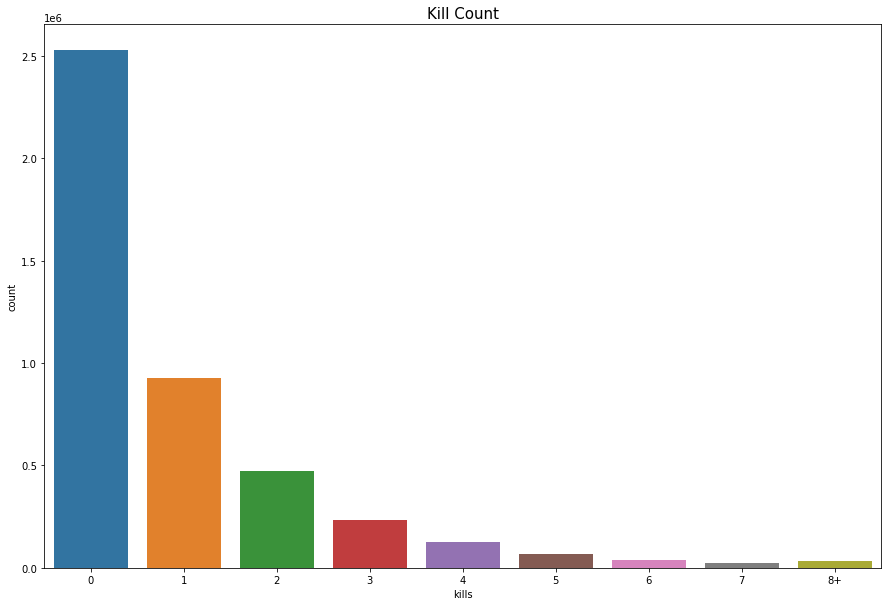

In [14]:
plt.figure(figsize=(15,10))
sns.countplot(data['kills'].astype('str').sort_values())
plt.title("Kill Count",fontsize=15)
plt.show()

### Most people can't make a single kill. At least do they do damage?



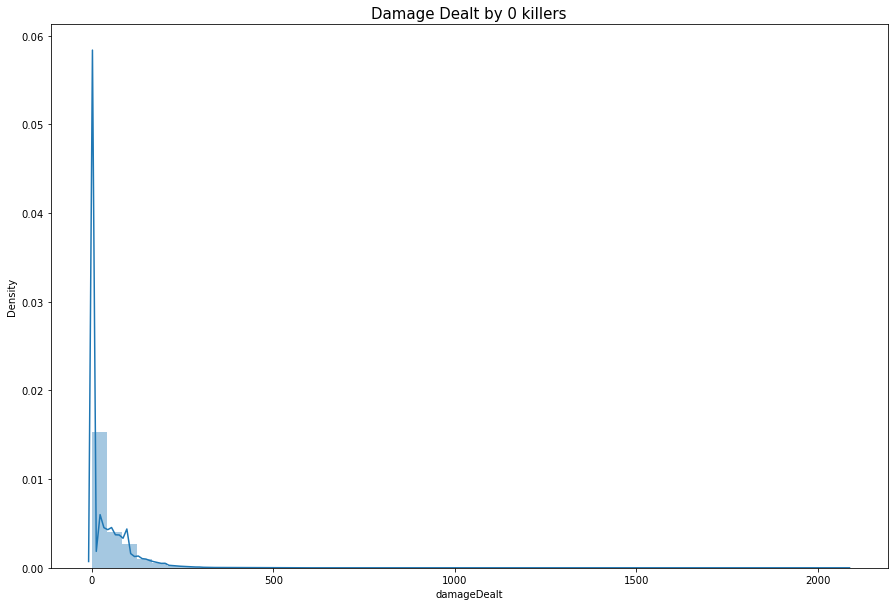

In [15]:
data = df.copy()
data = data[data['kills']==0]
plt.figure(figsize=(15,10))
plt.title("Damage Dealt by 0 killers",fontsize=15)
sns.distplot(data['damageDealt'])
plt.show()

In [16]:
print("{} players ({:.4f}%) have won without a single kill!"
      .format(len(data[data['winPlacePerc']==1]), 100*len(data[data['winPlacePerc']==1])/len(df)))

16666 players (0.3748%) have won without a single kill!


In [17]:
data1 = df[df['damageDealt'] == 0].copy()
print("{} players ({:.4f}%) have won without dealing damage!"
      .format(len(data1[data1['winPlacePerc']==1]), 100*len(data1[data1['winPlacePerc']==1])/len(df)))

4770 players (0.1073%) have won without dealing damage!


### Plot win placement percentage vs kills.



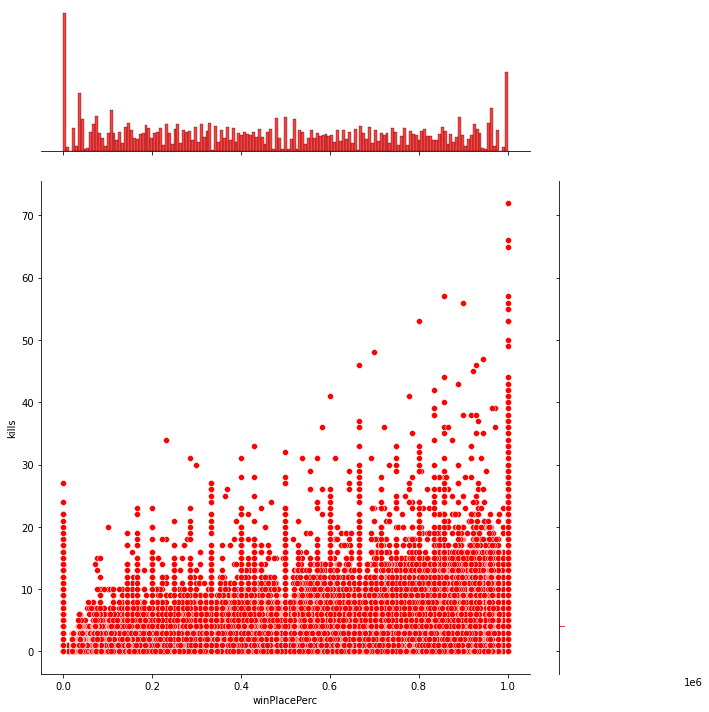

In [18]:
sns.jointplot(x="winPlacePerc", y="kills", data=df, height=10, ratio=3, color="r")
plt.show()

#### Apparentrly killing has a correlation with winning. Finally let's group players based on kills (0 kills, 1-2 kills, 3-5 kills, 6-10 kills and 10+ kills).

In [19]:
kills = df.copy()
kills['killsCategories'] = pd.cut(kills['kills'], [-1, 0, 2, 5, 10, 60], labels=['0_kills','1-2_kills', '3-5_kills', '6-10_kills', '10+_kills'])

In [20]:
kills['killsCategories'].value_counts()

0_kills       2529722
1-2_kills     1400545
3-5_kills      423561
6-10_kills      84798
10+_kills        8337
Name: killsCategories, dtype: int64

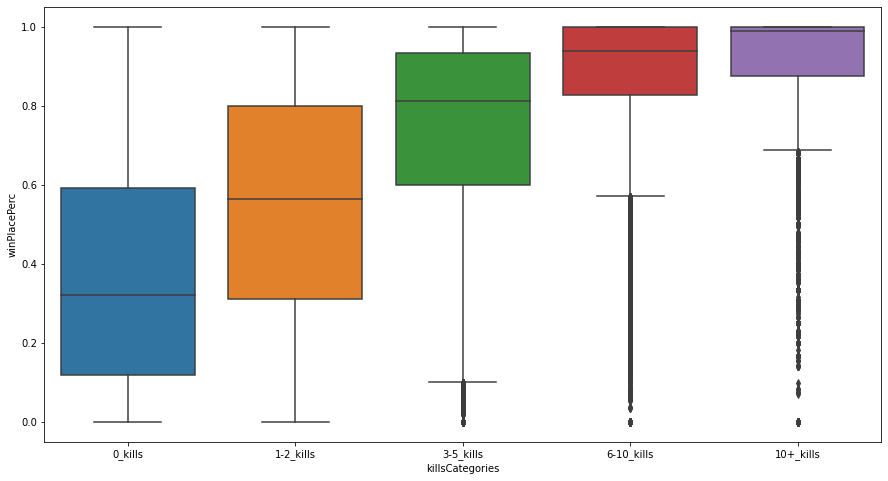

In [21]:
plt.figure(figsize=(15,8))
sns.boxplot(x="killsCategories", y="winPlacePerc", data=kills)
plt.show()

## The Runners

In [22]:
print("The average person walks for {:.1f}m, 99% of people have walked {}m or less, while the marathoner champion walked for {}m."
      .format(df['walkDistance'].mean(), 
              df['walkDistance'].quantile(0.99), 
              df['walkDistance'].max()))

The average person walks for 1148.5m, 99% of people have walked 4396.0m or less, while the marathoner champion walked for 25780.0m.


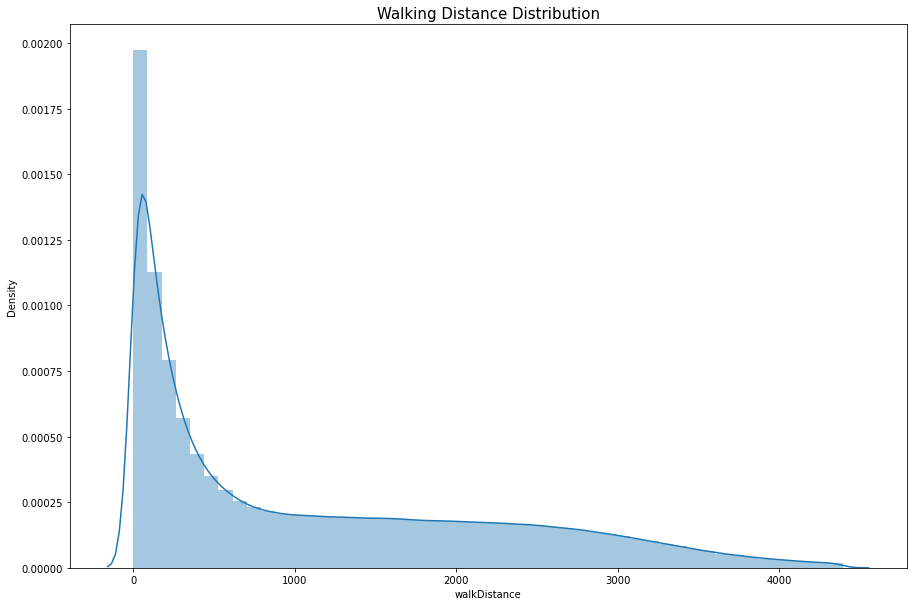

In [23]:
data = df.copy()
data = data[data['walkDistance'] < df['walkDistance'].quantile(0.99)]
plt.figure(figsize=(15,10))
plt.title("Walking Distance Distribution",fontsize=15)
sns.distplot(data['walkDistance'])
plt.show()

In [24]:
print("{} players ({:.4f}%) walked 0 meters. This means that they die before even taking a step or they are afk (more possible)."
      .format(len(data[data['walkDistance'] == 0]), 100*len(data1[data1['walkDistance']==0])/len(df)))

99603 players (2.0329%) walked 0 meters. This means that they die before even taking a step or they are afk (more possible).


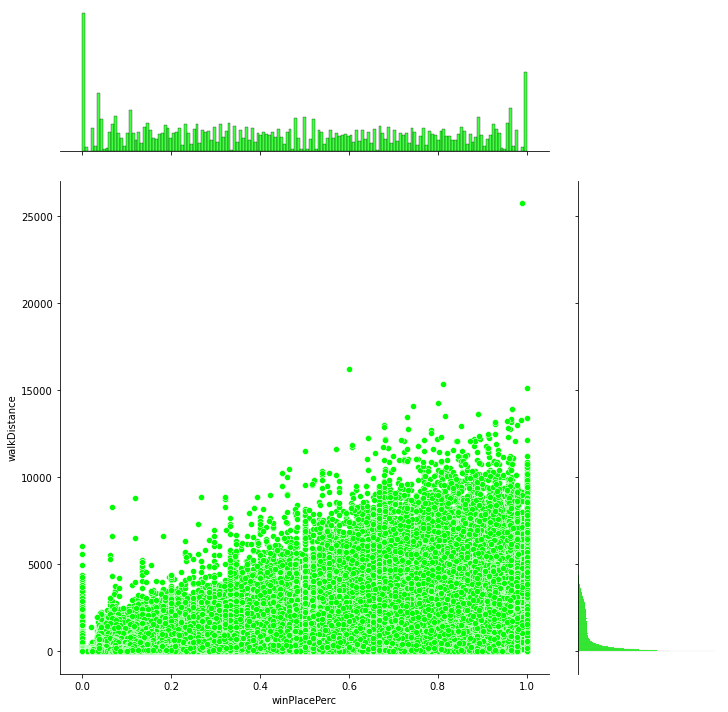

In [25]:
sns.jointplot(x="winPlacePerc", y="walkDistance",  data=df, height=10, ratio=3, color="lime")
plt.show()

## Apparently walking has a high correlation with winPlacePerc.

## The Drivers

In [26]:
print("The average person drives for {:.1f}m, 99% of people have drived {}m or less, while the formula 1 champion drived for {}m."
      .format(df['rideDistance'].mean(), 
        df['rideDistance'].quantile(0.99),
        df['rideDistance'].max()))

The average person drives for 606.1m, 99% of people have drived 6966.0m or less, while the formula 1 champion drived for 40710.0m.


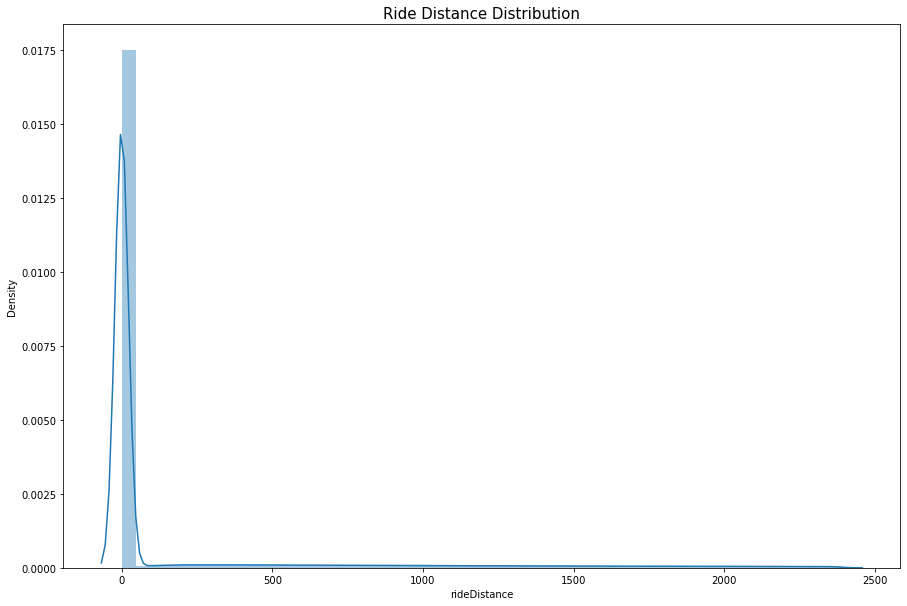

In [34]:
data = df.copy()
data = data[data['rideDistance'] < df['rideDistance'].quantile(0.9)]
plt.figure(figsize=(15,10))
plt.title("Ride Distance Distribution",fontsize=15)
sns.distplot(data['rideDistance'])
plt.show()

In [35]:
print("{} players ({:.4f}%) drived for 0 meters. This means that they don't have a driving licence yet."
      .format(len(data[data['rideDistance'] == 0]), 100*len(data1[data1['rideDistance']==0])/len(df)))

3309429 players (23.1022%) drived for 0 meters. This means that they don't have a driving licence yet.


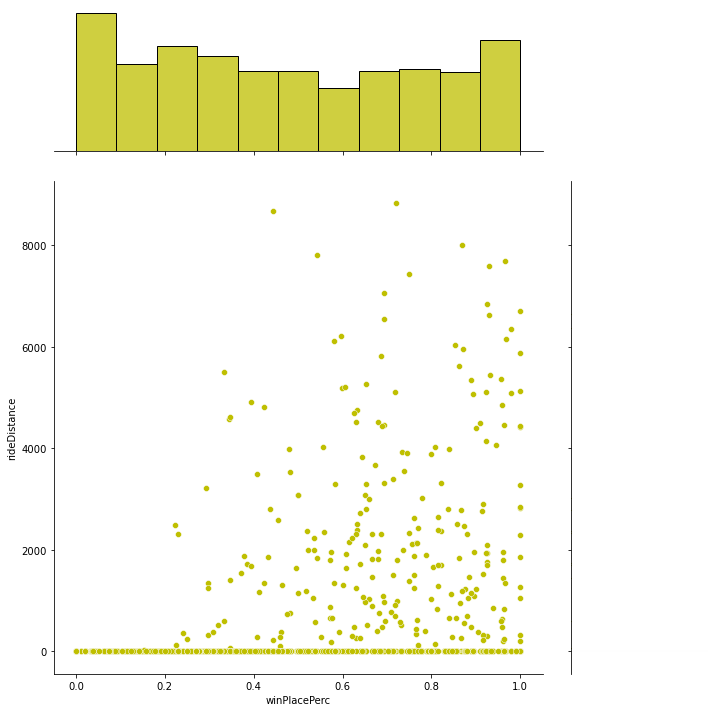

In [36]:
sns.jointplot(x="winPlacePerc", y="rideDistance", data=df[0:1000], height=10, ratio=3, color="y")
plt.show()

## There is a small correlation between rideDistance and winPlacePerc

#### Destroying a vehicle in my experience shows that a player has skills. Let's check it.

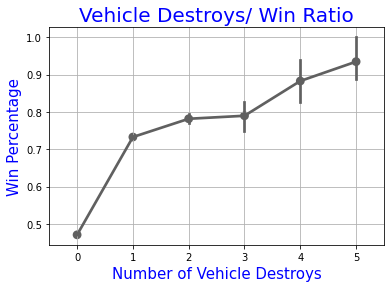

In [38]:
# f,ax1 = plt.subplots(figsize =(20,10))
sns.pointplot(x='vehicleDestroys',y='winPlacePerc',data=df.copy(),color='#606060',alpha=0.8)
plt.xlabel('Number of Vehicle Destroys',fontsize = 15,color='blue')
plt.ylabel('Win Percentage',fontsize = 15,color='blue')
plt.title('Vehicle Destroys/ Win Ratio',fontsize = 20,color='blue')
plt.grid()
plt.show()

## My experience was correct. Destroying a single vehicle increases your chances of winning!

## The Swimmers

In [39]:
print("The average person swims for {:.1f}m, 99% of people have swimemd {}m or less, while the olympic champion swimmed for {}m.".
      format(df['swimDistance'].mean(), 
             df['swimDistance'].quantile(0.99),
             df['swimDistance'].max()))

The average person swims for 4.5m, 99% of people have swimemd 123.0m or less, while the olympic champion swimmed for 3823.0m.


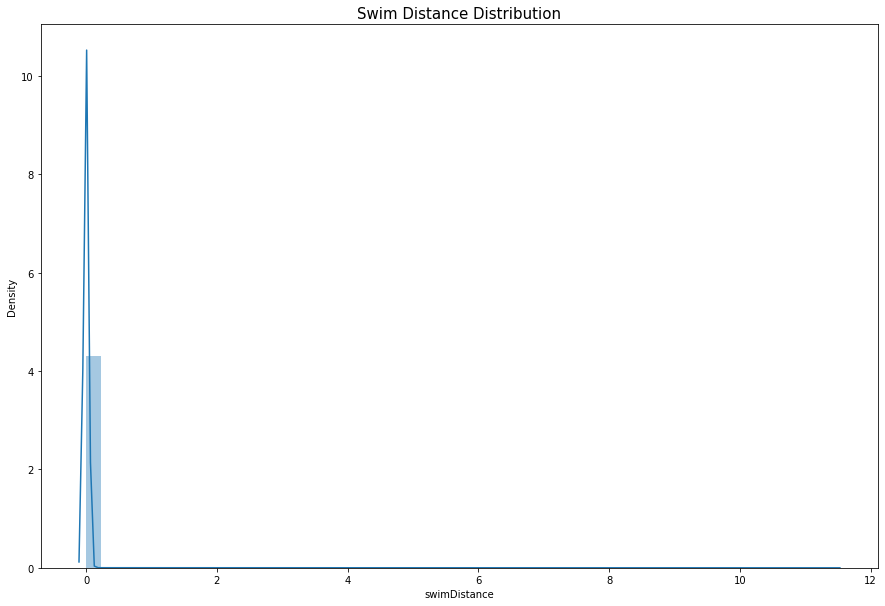

In [43]:
data = df.copy()
data = data[data['swimDistance'] < df['swimDistance'].quantile(0.95)]
plt.figure(figsize=(15,10))
plt.title("Swim Distance Distribution",fontsize=15)
sns.distplot(data['swimDistance'])
plt.show()

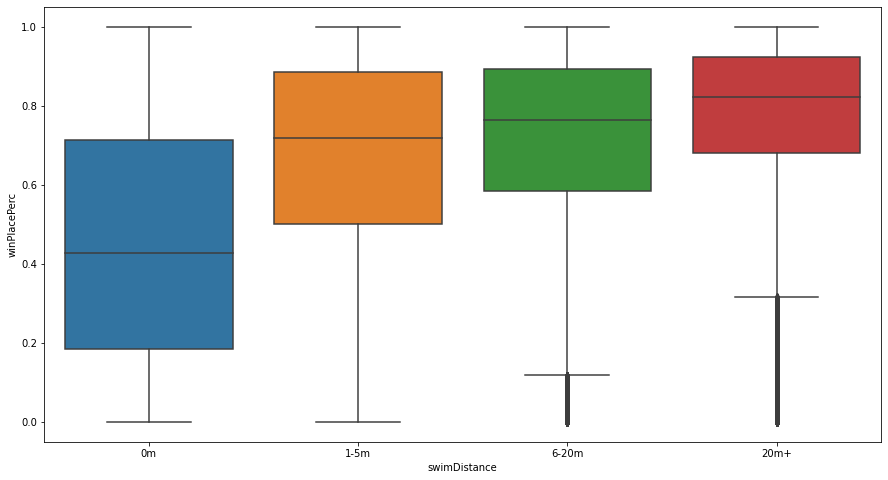

In [44]:
swim = df.copy()

swim['swimDistance'] = pd.cut(swim['swimDistance'], [-1, 0, 5, 20, 5286], labels=['0m','1-5m', '6-20m', '20m+'])

plt.figure(figsize=(15,8))
sns.boxplot(x="swimDistance", y="winPlacePerc", data=swim)
plt.show()

#### It seems that if you swim, you rise to the top. In PUBG there are currently 3 maps. One of them has almost no water. Keep that in mind. I might plan on doing analysis to find out in which map a match is played.

## The Healers

In [45]:
print("The average person uses {:.1f} heal items, 99% of people use {} or less, while the doctor used {}.".
      format(df['heals'].mean(), 
             df['heals'].quantile(0.99),
             df['heals'].max()))
print("The average person uses {:.1f} boost items, 99% of people use {} or less, while the doctor used {}."
      .format(df['boosts'].mean(),
        df['boosts'].quantile(0.99),
        df['boosts'].max()))

The average person uses 1.4 heal items, 99% of people use 12.0 or less, while the doctor used 80.
The average person uses 1.1 boost items, 99% of people use 7.0 or less, while the doctor used 33.


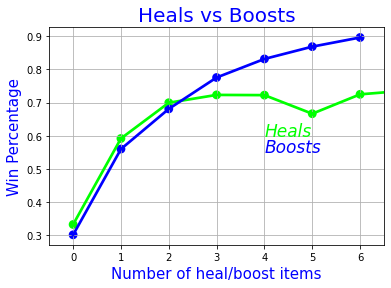

In [50]:
data = df.copy()
data = data[data['heals'] < data['heals'].quantile(0.99)]
data = data[data['boosts'] < data['boosts'].quantile(0.99)]

# f,ax1 = plt.subplots(figsize =(20,10))
sns.pointplot(x='heals',y='winPlacePerc',data=data,color='lime',alpha=0.8)
sns.pointplot(x='boosts',y='winPlacePerc',data=data,color='blue',alpha=0.8)
plt.text(4,0.6,'Heals',color='lime',fontsize = 17,style = 'italic')
plt.text(4,0.55,'Boosts',color='blue',fontsize = 17,style = 'italic')
plt.xlabel('Number of heal/boost items',fontsize = 15,color='blue')
plt.ylabel('Win Percentage',fontsize = 15,color='blue')
plt.title('Heals vs Boosts',fontsize = 20,color='blue')
plt.grid()
plt.show()

## Solos, Duos and Squads

#### There are 3 game modes in the game. One can play solo, or with a friend (duo), or with 3 other friends (squad). 100 players join the same server, so in the case of duos the max teams are 50 and in the case of squads the max teams are 25.

In [52]:
solos = df[df['numGroups']>50]
duos = df[(df['numGroups']>25) & (df['numGroups']<=50)]
squads = df[df['numGroups']<=25]


In [55]:
print("There are {} ({:.2f}%) solo games, {} ({:.2f}%) duo games and {} ({:.2f}%) squad games."
      .format(len(solos), 100*len(solos)/len(df),
              len(duos), 100*len(duos)/len(df),
              len(squads), 100*len(squads)/len(df),))

There are 709111 (15.95%) solo games, 3295326 (74.10%) duo games and 442529 (9.95%) squad games.


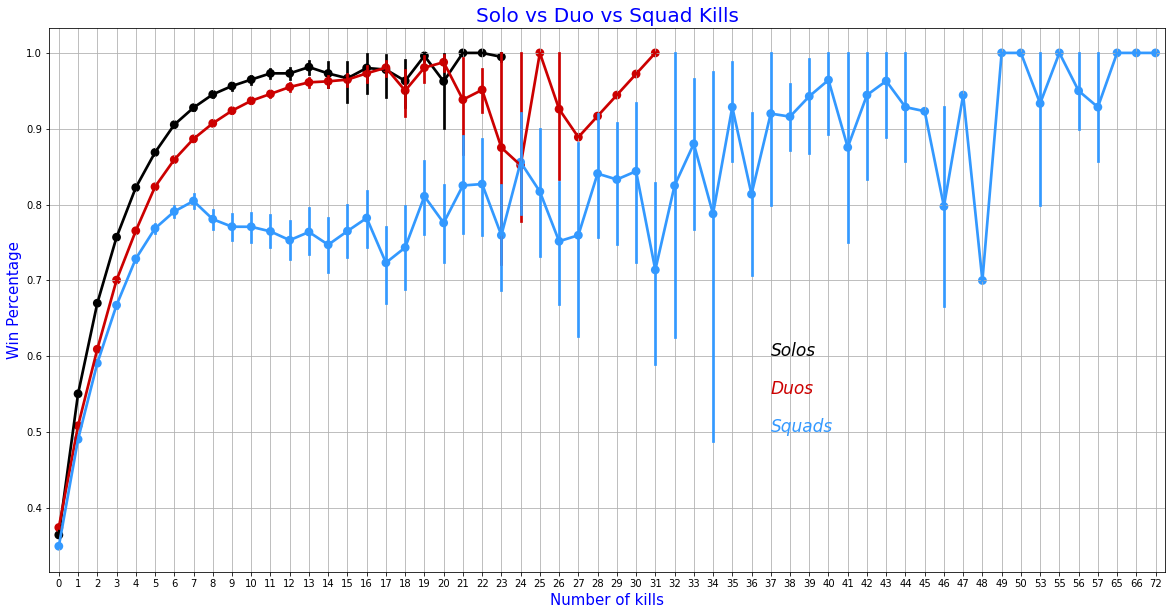

In [56]:
f,ax1 = plt.subplots(figsize =(20,10))
sns.pointplot(x='kills',y='winPlacePerc',data=solos,color='black',alpha=0.8)
sns.pointplot(x='kills',y='winPlacePerc',data=duos,color='#CC0000',alpha=0.8)
sns.pointplot(x='kills',y='winPlacePerc',data=squads,color='#3399FF',alpha=0.8)
plt.text(37,0.6,'Solos',color='black',fontsize = 17,style = 'italic')
plt.text(37,0.55,'Duos',color='#CC0000',fontsize = 17,style = 'italic')
plt.text(37,0.5,'Squads',color='#3399FF',fontsize = 17,style = 'italic')
plt.xlabel('Number of kills',fontsize = 15,color='blue')
plt.ylabel('Win Percentage',fontsize = 15,color='blue')
plt.title('Solo vs Duo vs Squad Kills',fontsize = 20,color='blue')
plt.grid()
plt.show()

<p>Hmm, very interesting. Solos and duos behave the same, but when playing squads kills don't matter that much.</p>

#### The attribute DBNOs means enemy players knocked. A "knock" can happen only in duos or squads, because the teammates have the chance to "revive" the knocked player in a given time. So a knocked player can be revived or die. If he is revived, the next time he will be knocked, his teammates will have less time to revive him.

The attribute assist can also happen only in duos or squads. It generally means that the player had an involvement in a kill.

The attribute revive also happens in duos or squads.

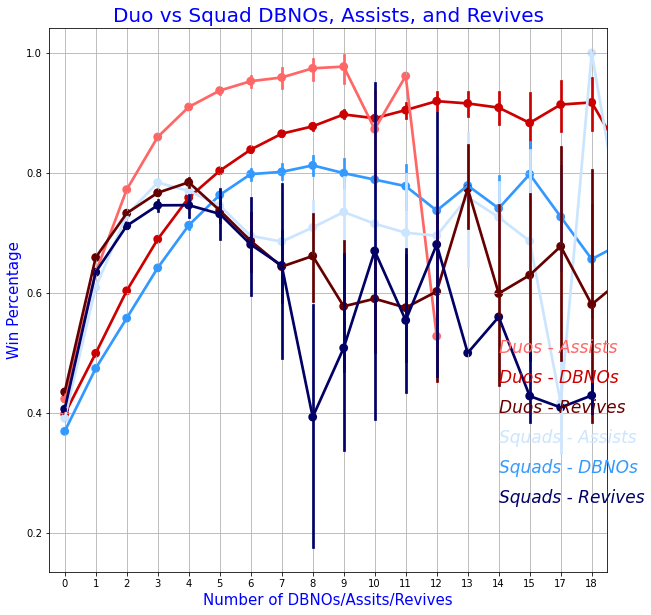

In [59]:
f,ax1 = plt.subplots(figsize =(10,10))
sns.pointplot(x='DBNOs',y='winPlacePerc',data=duos,color='#CC0000',alpha=0.8)
sns.pointplot(x='DBNOs',y='winPlacePerc',data=squads,color='#3399FF',alpha=0.8)
sns.pointplot(x='assists',y='winPlacePerc',data=duos,color='#FF6666',alpha=0.8)
sns.pointplot(x='assists',y='winPlacePerc',data=squads,color='#CCE5FF',alpha=0.8)
sns.pointplot(x='revives',y='winPlacePerc',data=duos,color='#660000',alpha=0.8)
sns.pointplot(x='revives',y='winPlacePerc',data=squads,color='#000066',alpha=0.8)
plt.text(14,0.5,'Duos - Assists',color='#FF6666',fontsize = 17,style = 'italic')
plt.text(14,0.45,'Duos - DBNOs',color='#CC0000',fontsize = 17,style = 'italic')
plt.text(14,0.4,'Duos - Revives',color='#660000',fontsize = 17,style = 'italic')
plt.text(14,0.35,'Squads - Assists',color='#CCE5FF',fontsize = 17,style = 'italic')
plt.text(14,0.3,'Squads - DBNOs',color='#3399FF',fontsize = 17,style = 'italic')
plt.text(14,0.25,'Squads - Revives',color='#000066',fontsize = 17,style = 'italic')
plt.xlabel('Number of DBNOs/Assits/Revives',fontsize = 15,color='blue')
plt.ylabel('Win Percentage',fontsize = 15,color='blue')
plt.title('Duo vs Squad DBNOs, Assists, and Revives',fontsize = 20,color='blue')
plt.grid()
plt.show()


### Pearson correlation between variables

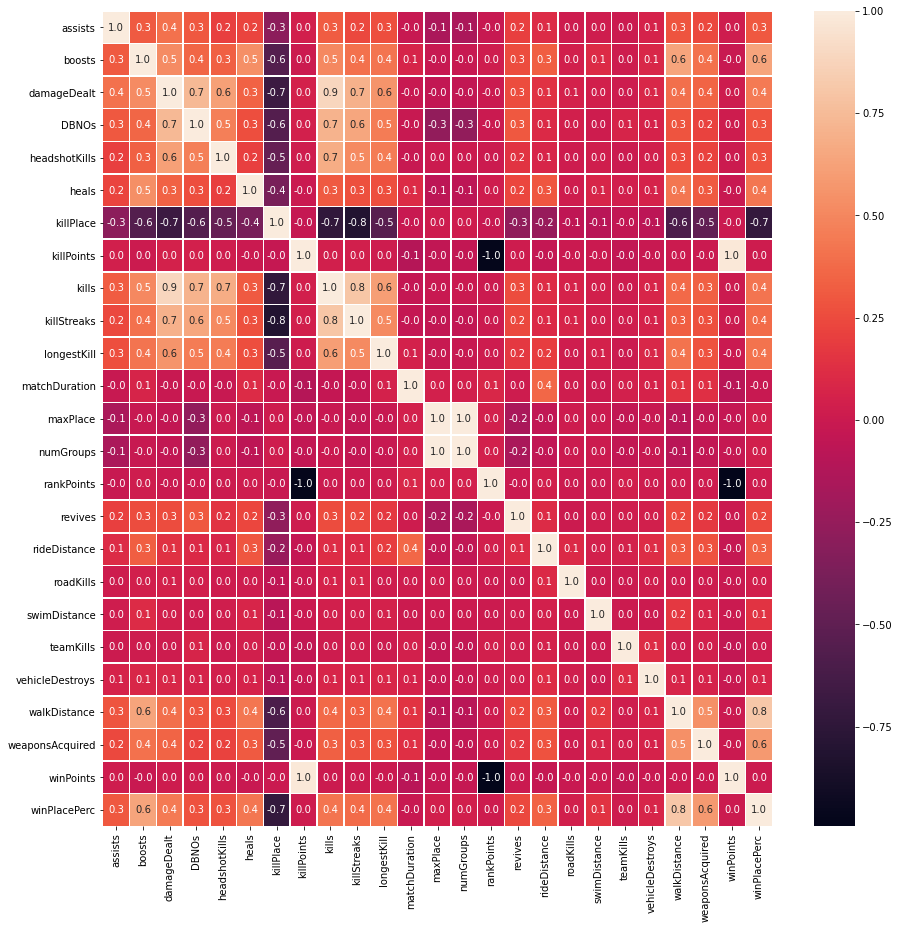

In [60]:
f,ax = plt.subplots(figsize=(15, 15))
sns.heatmap(df.corr(), annot=True, linewidths=.5, fmt= '.1f',ax=ax)
plt.show()

### In terms of the target variable (winPlacePerc), there are a few variables high medium to high correlation. The highest positive correlation is walkDistance and the highest negative the killPlace.

## Let's zoom to the top-5 most positive correlated variables with the target

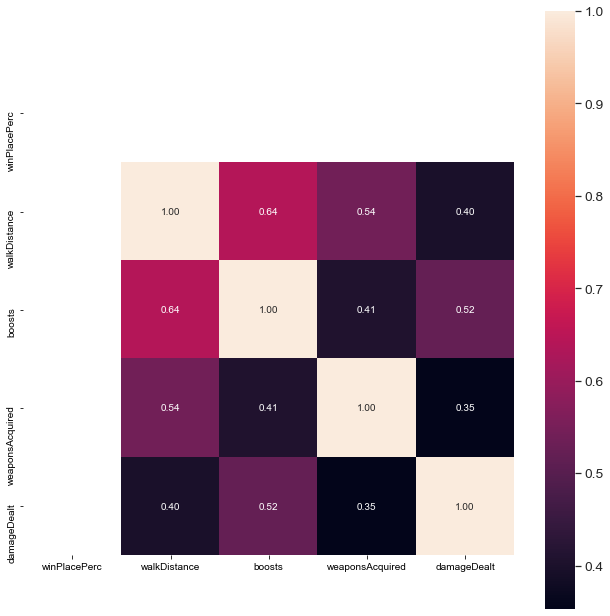

In [64]:
k = 5 #number of variables for heatmap
f,ax = plt.subplots(figsize=(11, 11))
cols = df.corr().nlargest(k, 'winPlacePerc')['winPlacePerc'].index
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.25)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

In [66]:
# sns.set()
# cols = ['winPlacePerc', 'walkDistance', 'boosts', 'weaponsAcquired', 'damageDealt', 'killPlace']
# sns.pairplot(df[cols], size = 2.5)
# plt.show()

In [67]:
df.groupby('matchId')['matchId'].transform('count')

0          96
1          91
2          98
3          91
4          97
           ..
4446961    94
4446962    93
4446963    98
4446964    94
4446965    98
Name: matchId, Length: 4446966, dtype: int64

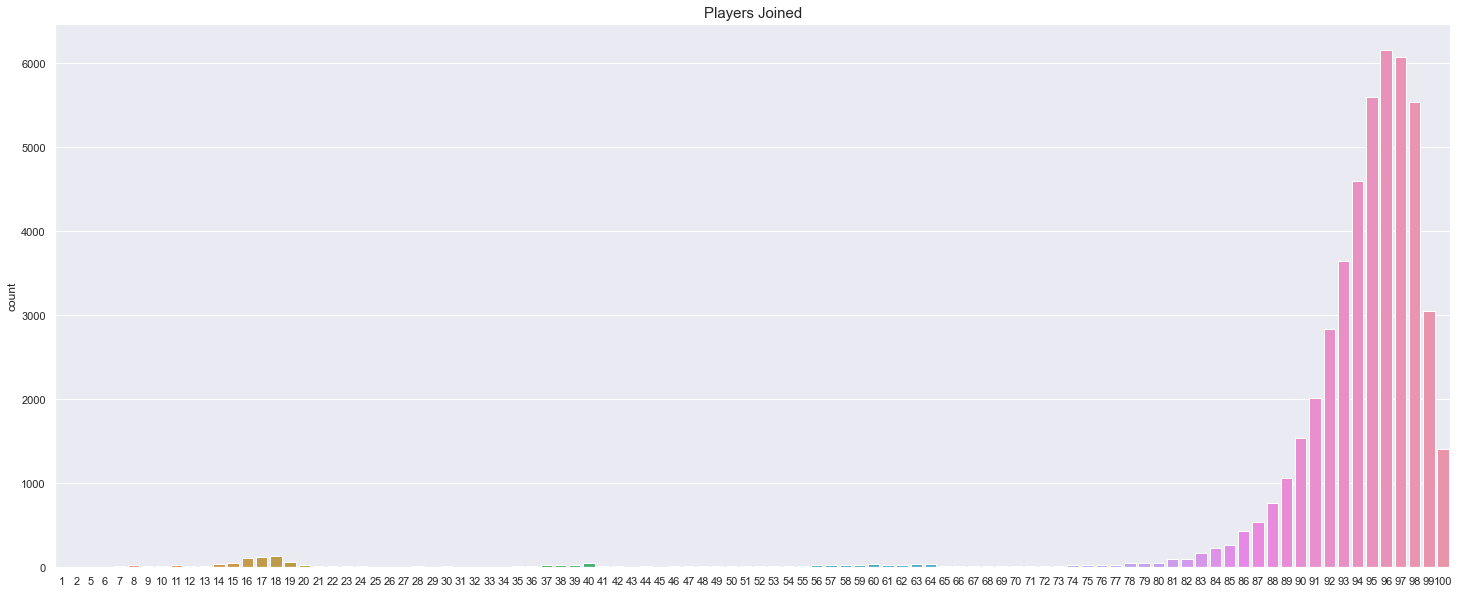

In [86]:
plt.figure(figsize=(25,10))
sns.countplot(data)
plt.title("Players Joined per match",fontsize=15)
plt.show()
